# Lensless Demo

Этот ноутбук скачивает чекпоинт, скачивает zip-датасет, запускает `inference.py`, показывает несколько примеров и считает метрики.

**Демо почти не требует действий от человека. Надо только вставить ссылку на google-drive архив и ещё выбрать модель из предложенных (см. ниже).**

In [ ]:
!pip install -q gdown==5.2.0 wget==3.2

In [3]:
from pathlib import Path
from zipfile import ZipFile
import subprocess

import gdown
import matplotlib.pyplot as plt
import wget
from PIL import Image

## Клонирование репозитория

Если ноутбук уже открыт внутри репозитория, эту ячейку можно пропустить.

In [ ]:
!git clone https://github.com/Zagonov/lensless-imaging.git
%cd lensless-imaging

## Установка зависимостей

In [ ]:
!pip install -q -r requirements.txt

## Параметры

В `MODEL_CONFIG` нужно определить конфиг модели, которую мы будем использовать. Это один из 5 возможных вариантов:
1. `admm_100`
2. `leadmm5_pre`
3. `leadmm5_post`
4. `leadmm5_pre_post`
5. `unrolled_admm_20`

Также указывается чекпоинт, из которого будет загружены параметры для данной модели. Если по `CHECKPOINT_PATH` нет нужного файла, чекпоинт скачивается по ссылке `CHECKPOINT_URL` в директорию, в которую ведёт `CHECKPOINT_PATH`.

**По умолчанию CHECKPOINT_PATH лучше просто не трогать, при скачивании из репы там будет пусто, а значит просто скачается файл из CHECKPOINT_URL.**

Также указывается `DATASET_URL` - ссылка на Google Drive, по которой можно скачать датасет, на котором будем прогонять инференс.

In [ ]:
# надо вставить желаемую модель
MODEL_CONFIG = "model name"

In [ ]:
links = {
    "admm_100": "https://huggingface.co/Lunfus/admm_100/resolve/main/admm_100_best.pth",
    "leadmm5_pre": "https://huggingface.co/Lunfus/leadmm5_pre/resolve/main/leadmm5_pre_best.pth",
    "leadmm5_post": "https://huggingface.co/Lunfus/leadmm5_post/resolve/main/leadmm5_post_best.pth",
    "leadmm5_pre_post": "https://huggingface.co/Lunfus/leadmm_5_pre_post/resolve/main/leadmm5_pre_post_best.pth",
    "unrolled_admm_20": "https://huggingface.co/Lunfus/unrolled_admm_20/resolve/main/unrolled_admm_20_best.pth"
}

CHECKPOINT_PATH = f"saved/{MODEL_CONFIG}/{MODEL_CONFIG}_best.pth"
CHECKPOINT_URL = links[MODEL_CONFIG]

In [ ]:
# надо вставить ссылку на датасет
DATASET_URL = "https://drive.google.com/file/d/1opc-95HBU3SWsM4_LJIz4ugO972tAVYb/view?usp=sharing"

Создаём необходимые пути, а также папки, если они ещё не существуют.

In [14]:
root = Path.cwd()
checkpoint_path = Path(CHECKPOINT_PATH)
if not checkpoint_path.is_absolute():
    checkpoint_path = root / checkpoint_path

zip_path = root / "downloads" / "dataset.zip"
unpack_dir = root / "data" / "demo_dataset"
output_dir = root / "saved" / "demo_inference"
predictions_dir = output_dir / "custom"

checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
zip_path.parent.mkdir(parents=True, exist_ok=True)
unpack_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

## Скачивание чекпоинта

Если `CHECKPOINT_PATH` в действительности не ведёт к реальному файлу, тогда скачиваем на это место чекпоинт по ссылке из `CHECKPOINT_URL`.

In [15]:
if not checkpoint_path.exists():
    wget.download(CHECKPOINT_URL, str(checkpoint_path))

## Скачивание и распаковка датасета

Здесь по ссылке `DATASET_URL` скачиавется и распакуется архив с датасетом.

**Поддерживается два варианта:** или распаковка архива сразу ведёт к 2 или 3 нужным папкам с картинками (lensless, lensed, masks), или внутри архива лежит ещё одна папка с датасетом, и только в ней уже папки с картинками. Во втором случае у меня просто в качестве папки с датасетом выберется внутренняя папка.

In [16]:
if not zip_path.exists():
    gdown.download(DATASET_URL, str(zip_path), quiet=False, fuzzy=True)

if not any(unpack_dir.iterdir()):
    with ZipFile(zip_path, "r") as archive:
        archive.extractall(unpack_dir)

dataset_dir = unpack_dir
if not (dataset_dir / "lensless").exists():
    subdirs = [path for path in unpack_dir.iterdir() if path.is_dir()]
    if len(subdirs) == 1:
        dataset_dir = subdirs[0]

print(dataset_dir)

/Users/dmitry/hse/dl-1/hw-5/data/demo_dataset/custom


## Запуск inference

Запуск инференса. Результаты сохарнятся в `output_dir`, которым является `root/saved/demo_inference` в общем случае. Инференс брался из шаблона, в нём уже зашит подсчёт и вывод метрик. Однако ещё дополнительно ниже будет вывод метрик через `calculate_metrics.py`.

In [ ]:
!python -u inference.py model={MODEL_CONFIG} inferencer.from_pretrained={checkpoint_path} datasets.custom.data_dir={dataset_dir} inferencer.save_path={output_dir}

ModularLeADMM(
  (preprocessor): DRUNet(
    (head): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down1): DownBlock(
      (block): Sequential(
        (0): ResidualBlock(
          (block): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
            (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (relu): ReLU()
        )
        (1): ResidualBlock(
          (block): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
            (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (relu): ReLU()
        )
        (2): ResidualBlock(
          (block): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
            (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), paddin

custom: 100%|██████████| 4/4 [00:44<00:00, 11.12s/it]


custom_MSE: 0.03448222205042839
custom_PSNR: 14.775534391403198
custom_SSIM: 0.3120517171919346
custom_LPIPS: 0.6914104223251343


CompletedProcess(args=['python', 'inference.py', 'model=leadmm5_pre', 'inferencer.from_pretrained=/Users/dmitry/hse/dl-1/hw-5/saved/leadmm5_pre/leadmm5_pre_best.pth', 'datasets.custom.data_dir=/Users/dmitry/hse/dl-1/hw-5/data/demo_dataset/custom', 'inferencer.save_path=/Users/dmitry/hse/dl-1/hw-5/saved/demo_inference'], returncode=0)

## Примеры

Вывод примеров. Если нет оригинала (lensed изображения), то просто выведется "no original".

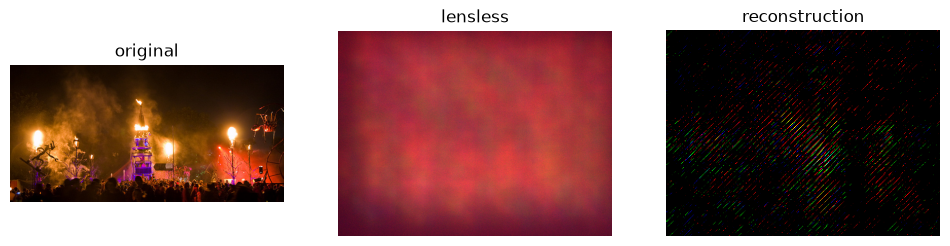

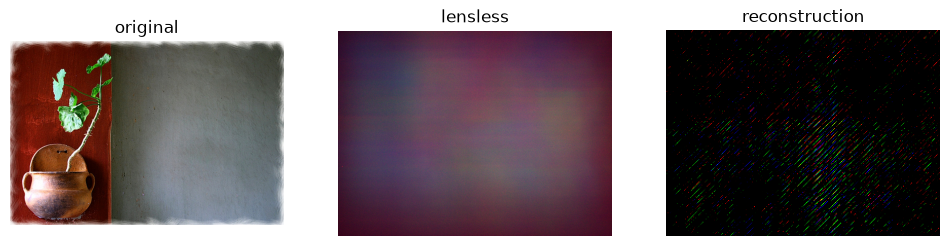

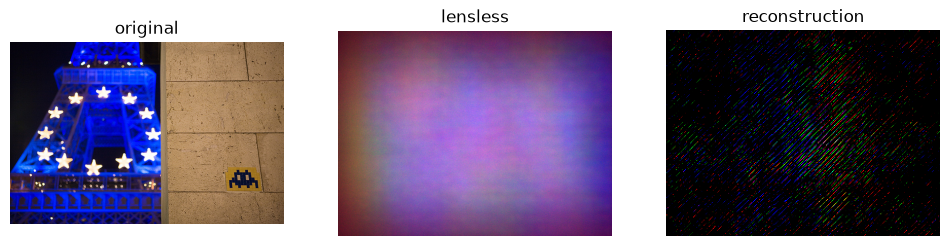

In [10]:
lensless_dir = dataset_dir / "lensless"
original_dir = dataset_dir / "lensed"

image_ids = sorted(path.stem for path in predictions_dir.glob("*.png"))[:3]

for image_id in image_ids:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    original_path = original_dir / f"{image_id}.png"
    lensless_path = lensless_dir / f"{image_id}.png"
    prediction_path = predictions_dir / f"{image_id}.png"

    if original_path.exists():
        axes[0].imshow(Image.open(original_path).convert("RGB"))
    else:
        axes[0].text(0.5, 0.5, "no original", ha="center", va="center")

    axes[0].set_title("original")
    axes[1].imshow(Image.open(lensless_path).convert("RGB"))
    axes[1].set_title("lensless")
    axes[2].imshow(Image.open(prediction_path).convert("RGB"))
    axes[2].set_title("reconstruction")

    for axis in axes:
        axis.axis("off")

    plt.show()

## Метрики

Вывод метрик через `calculate_metrics.py`. Возможен, только если в датасете есть папка с lensed изображениями.

In [ ]:
!python calculate_metrics.py --data-dir {str(dataset_dir)} --predictions-dir {str(predictions_dir)}

metrics: 100%|██████████| 8/8 [00:01<00:00,  5.18it/s]


num images: 8
MSE: 0.18079791776835918
PSNR: 7.696144163608551
SSIM: 0.05955056060338393
LPIPS: 0.7916728556156158
